# affect_aif Demo Notebook

**Open In Colab:** anonymous review repository: <https://anonymous.4open.science/r/affect_aif>. Override `AFFECT_AIF_REPO_URL` if you use a git-cloneable mirror.

This is the guided public walkthrough for the project. It runs the small demo configs, then turns each output into a mechanism-level read: where confidence moves, when policy entropy changes, and why payoff is only one part of the story.

The default route runs the four core demos only (21 expanded runs). The appendix/profile demos are opt-in and bring the full demo route to 42 expanded runs. Treat all plots as an executable map of the mechanism, not as publication-scale evidence.

## Tour Map

The notebook has two routes.

Default core route (21 expanded runs):

1. Predictability over value: confidence follows partner reliability more than reward alone.
2. Deployment ablation: confidence matters when it reaches policy precision, producing lower entropy with nearly matched payoff in the paper run.
3. Partner selection: local confidence reorganizes partner choice; the current paper readout is not a one-type preference or payoff headline.
4. Betrayal adaptation: accumulated confidence changes entropy, accuracy, and response after a stance change.

Opt-in appendix/profile route (adds 21 expanded runs):

5. Alpha sweep: gain changes confidence amplitude and commitment.
6. Prior x gain factorial: starting beliefs and gain form computational profiles.
7. Forgiveness: reengagement and restored confidence can separate.

Each section asks a question, runs a current `configs/demo/` TOML, shows compact summaries, and points back to the matching paper config.

## 1. Bootstrap Runtime

In Colab, this clones the selected branch and moves into the repo. Locally, it searches upward from the notebook directory. The command-line scripts remain the source of truth; the notebook is a guided interface over those scripts.


In [1]:
from pathlib import Path
import os
import platform
import shutil
import subprocess
import sys

try:
    import google.colab  # type: ignore[import-not-found]
    IN_COLAB = True
except Exception:
    IN_COLAB = Path("/content").exists()

def sanitize_repo_url(value):
    value = str(value).strip()
    if value.startswith("[") and "](" in value and value.endswith(")"):
        value = value.split("](", 1)[1][:-1]
    if value.startswith("<") and value.endswith(">"):
        value = value[1:-1]
    return value.strip()


REPO_URL = sanitize_repo_url(os.environ.get("AFFECT_AIF_REPO_URL", "https://anonymous.4open.science/r/affect_aif"))
BRANCH = os.environ.get("AFFECT_AIF_BRANCH", "master")


def clone_repo(repo_url, branch, repo_dir):
    cmd = ["git", "clone", "--depth", "1", "--branch", branch, repo_url, str(repo_dir)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("Git clone failed.")
        print("Command:", " ".join(cmd))
        print("stdout:", result.stdout.strip() or "<empty>")
        print("stderr:", result.stderr.strip() or "<empty>")
        raise subprocess.CalledProcessError(result.returncode, cmd, output=result.stdout, stderr=result.stderr)


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "scripts/experiment/run.py").exists() and (candidate / "configs/demo").exists():
            return candidate
    return None


existing_root = find_repo_root(Path.cwd())
if existing_root is not None:
    os.chdir(existing_root)
elif IN_COLAB:
    repo_dir = Path("/content/affect_aif")
    if repo_dir.exists() and not (repo_dir / ".git").exists():
        shutil.rmtree(repo_dir)
    if not repo_dir.exists():
        clone_repo(REPO_URL, BRANCH, repo_dir)
    os.chdir(repo_dir)
else:
    raise RuntimeError("Could not find affect_aif repo root from the current notebook directory.")

print("Working directory:", Path.cwd())
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())


Working directory: /Users/harshilshah/Desktop/Active Inference/affect_aif
Python: 3.10.19
Platform: macOS-26.5.1-arm64-arm-64bit


## 2. Install Dependencies

Colab runtimes are fresh, so install the repo there by default. Local users can set `INSTALL_DEPS = True` if their kernel does not already have the package installed.


In [2]:
INSTALL_DEPS = IN_COLAB

if INSTALL_DEPS:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], check=True)
    print("Installed affect_aif in editable mode for this runtime.")
else:
    print("Skipped dependency install. Set INSTALL_DEPS = True if imports fail.")


Skipped dependency install. Set INSTALL_DEPS = True if imports fail.


## 3. Check Runtime Device

These demos are designed to run on CPU. The device check is here so public readers can see what JAX is using before they launch experiments.


In [3]:
def detect_accelerator():
    try:
        import jax
        devices = [str(device) for device in jax.devices()]
    except Exception as exc:
        return "gpu" if shutil.which("nvidia-smi") else "cpu", [f"JAX unavailable: {exc}"]

    gpu_devices = [device for device in devices if "gpu" in device.lower() or "cuda" in device.lower()]
    if gpu_devices:
        return "gpu", devices
    return "cpu", devices

DEVICE, JAX_DEVICES = detect_accelerator()
print("Selected device:", DEVICE)
print("JAX devices:", JAX_DEVICES)

if DEVICE == "gpu" and shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)
elif DEVICE == "cpu":
    print("No GPU detected; the demo will run on CPU.")


Selected device: cpu
JAX devices: ['TFRT_CPU_0']
No GPU detected; the demo will run on CPU.


## 4. Choose Your Route And Analysis Helpers

Use `DEMO_ROUTE = "core"` for the reviewer-friendly first pass. Switch to `"profiles"` when you want the appendix/profile demos too, or use `"custom"` and edit `CUSTOM_DEMOS`.

The helper functions below do three jobs: run configs through `scripts/experiment/run.py`, run generic analysis through `scripts/analysis/analyze.py`, and display compact reviewer scaffolds after each run.

In [4]:
RUN_DEMO = True
RUN_ANALYSIS = True
RESET_OUTPUTS = False
OUTPUT_ROOT = Path("outputs")
DEMO_BATCH_PREFIX = "notebook_demo"

DEMO_ROUTE = "core"  # "core", "profiles", "all", or "custom"
CORE_DEMOS = ["predictability_value", "deployment_ablation", "partner_selection", "betrayal_adaptation"]
PROFILE_DEMOS = ["alpha_sweep", "prior_factorial", "forgiveness"]
CUSTOM_DEMOS = CORE_DEMOS.copy()

if DEMO_ROUTE == "core":
    SELECTED_DEMOS = CORE_DEMOS
    RUN_OPTIONAL_DEMOS = False
elif DEMO_ROUTE in {"profiles", "all"}:
    SELECTED_DEMOS = CORE_DEMOS + PROFILE_DEMOS
    RUN_OPTIONAL_DEMOS = True
elif DEMO_ROUTE == "custom":
    SELECTED_DEMOS = CUSTOM_DEMOS
    RUN_OPTIONAL_DEMOS = any(name in PROFILE_DEMOS for name in CUSTOM_DEMOS)
else:
    raise ValueError(f"Unknown DEMO_ROUTE: {DEMO_ROUTE!r}")

DEMO_EXPERIMENTS = {
    "predictability_value": {
        "config": "configs/demo/01_predictability_value.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_01_predictability_value",
        "paper_config": "configs/paper/01_predictability_value.toml",
        "label": "1. Predictability over value",
        "question": "Does confidence track partner predictability more directly than realized payoff?",
        "readout": "Compare payoff, policy entropy, predictive evidence, and model-fitness tables.",
        "change": "Reliability and evidence readouts should move separately from tiny-run payoff noise.",
        "avoid": "Do not treat this demo-scale payoff ordering as the paper claim.",
        "paper_section": "Section 3.1",
        "demo_runs": 6,
        "paper_runs": 90,
        "optional": False,
    },
    "deployment_ablation": {
        "config": "configs/demo/02_deployment_ablation.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_02_deployment_ablation",
        "paper_config": "configs/paper/02_deployment_ablation.toml",
        "label": "2. Deployment ablation",
        "question": "Does affective precision matter because it changes action deployment, not because it adds new observations?",
        "readout": "Look for lower entropy through beta-to-gamma deployment while payoff remains nearly matched.",
        "change": "Tracked-only keeps the beta trace visible while blocking its action-selection route.",
        "avoid": "Do not write this as a broad payoff advantage; the paper readout is policy commitment.",
        "paper_section": "Section 3.2",
        "demo_runs": 4,
        "paper_runs": 120,
        "optional": False,
    },
    "partner_selection": {
        "config": "configs/demo/03_partner_selection.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_03_partner_selection",
        "paper_config": "configs/paper/03_partner_selection.toml",
        "label": "3. Partner selection",
        "question": "Does partner-local precision reshape who the agent chooses to engage?",
        "readout": "Inspect selected-partner rates, partner-type summaries, and entropy; avoid a one-type preference or payoff headline.",
        "change": "Partner-local precision can reorganize social allocation when partner choice is available.",
        "avoid": "Do not collapse the readout into cooperator preference or total payoff.",
        "paper_section": "Section 3.3",
        "demo_runs": 3,
        "paper_runs": 90,
        "optional": False,
    },
    "betrayal_adaptation": {
        "config": "configs/demo/04_betrayal_adaptation.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_04_betrayal_adaptation",
        "paper_config": "configs/paper/04_betrayal_adaptation.toml",
        "label": "4. Betrayal adaptation",
        "question": "What happens when confidence accumulated under cooperation meets a sudden stance change?",
        "readout": "Read entropy, joint accuracy, reallocation, and post-switch phase summaries together.",
        "change": "The stance switch tests whether accumulated confidence remains behaviorally consequential under change.",
        "avoid": "Do not call this generic recovery or a clean payoff win.",
        "paper_section": "Section 3.4",
        "demo_runs": 8,
        "paper_runs": 120,
        "optional": False,
    },
    "alpha_sweep": {
        "config": "configs/demo/05a_alpha_sweep.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_05a_alpha_sweep",
        "paper_config": "configs/paper/05a_alpha_sweep.toml",
        "label": "5a. Alpha sweep",
        "question": "How does gain change confidence amplitude and policy commitment?",
        "readout": "Use appendix-style profile plots: gain changes confidence amplitude, entropy, and commitment without implying a monotone payoff ranking.",
        "change": "Gain changes confidence-reactivity amplitude and can reshape commitment.",
        "avoid": "Do not rank alpha settings by payoff alone.",
        "paper_section": "Section 3.5 / Appendix",
        "demo_runs": 6,
        "paper_runs": 320,
        "optional": True,
    },
    "prior_factorial": {
        "config": "configs/demo/05b_prior_factorial.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_05b_prior_factorial",
        "paper_config": "configs/paper/05b_prior_factorial.toml",
        "label": "5b. Prior x gain factorial",
        "question": "How do starting trust priors and precision gain combine into computational profiles?",
        "readout": "Compare profile-level payoff, entropy, partner choice, and compact phenotype validation tables.",
        "change": "Trust priors and gain create profile signatures across environments.",
        "avoid": "Do not reduce the profile grid to a single winning phenotype.",
        "paper_section": "Section 3.5 / Appendix",
        "demo_runs": 12,
        "paper_runs": 360,
        "optional": True,
    },
    "forgiveness": {
        "config": "configs/demo/05c_forgiveness.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_05c_forgiveness",
        "paper_config": "configs/paper/05c_forgiveness.toml",
        "label": "5c. Forgiveness",
        "question": "Can reengagement recover without restored confidence?",
        "readout": "Read post-switch reengagement, beta movement, and payoff recovery as separate axes.",
        "change": "Reengagement can return before the same confidence trajectory is restored.",
        "avoid": "Do not read forgiveness as a moral label or a monotone confidence reset.",
        "paper_section": "Section 3.5 / Appendix",
        "demo_runs": 3,
        "paper_runs": 120,
        "optional": True,
    },
}

for spec in DEMO_EXPERIMENTS.values():
    if not Path(spec["config"]).exists():
        raise FileNotFoundError(spec["config"])
    if not Path(spec["paper_config"]).exists():
        raise FileNotFoundError(spec["paper_config"])

if RESET_OUTPUTS:
    for spec in DEMO_EXPERIMENTS.values():
        batch_dir = OUTPUT_ROOT / spec["batch"]
        if batch_dir.exists():
            shutil.rmtree(batch_dir)

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)


def selected_demo_names():
    if SELECTED_DEMOS == "all":
        return list(DEMO_EXPERIMENTS)
    return list(SELECTED_DEMOS)


def route_summary():
    names = selected_demo_names()
    rows = []
    for name in names:
        spec = DEMO_EXPERIMENTS[name]
        rows.append({
            "demo": name,
            "route": "profile" if spec.get("optional") else "core",
            "demo_runs": spec["demo_runs"],
            "paper_runs": spec["paper_runs"],
            "paper_config": spec["paper_config"],
        })
    summary = pd.DataFrame(rows)
    display(summary)
    print("Selected demo route:", DEMO_ROUTE)
    print("Expanded demo runs:", int(summary["demo_runs"].sum()) if not summary.empty else 0)
    print("Full demo route is 42 expanded runs; full paper route is 1220 expanded runs.")
    if not RUN_OPTIONAL_DEMOS:
        print("Appendix/profile demos are opt-in. Set DEMO_ROUTE = 'profiles' to add alpha, prior, and forgiveness demos.")
    return summary


def run_required(cmd, required_path=None):
    if required_path is not None and not Path(required_path).exists():
        raise FileNotFoundError(required_path)
    print("Running:", " ".join(map(str, cmd)))
    subprocess.run([str(x) for x in cmd], check=True)


def result_paths_for_batch(batch_name):
    batch_dir = OUTPUT_ROOT / batch_name
    return sorted(batch_dir.glob("**/results.csv"))


def analysis_dirs_for_paths(paths):
    return sorted({path.parent / "notebook_analysis" for path in paths if (path.parent / "notebook_analysis").exists()})


def run_demo_experiment(name):
    spec = DEMO_EXPERIMENTS[name]
    if name not in selected_demo_names():
        print(f"Skipping {spec['label']}. Add {name!r} to SELECTED_DEMOS to run it.")
        return []
    if spec.get("optional") and not RUN_OPTIONAL_DEMOS:
        print(f"Skipping optional demo: {spec['label']}. Set RUN_OPTIONAL_DEMOS = True to run it.")
        return []

    cmd = [
        sys.executable,
        "scripts/experiment/run.py",
        "--config",
        spec["config"],
        "--output-dir",
        str(OUTPUT_ROOT),
        "--batch-name",
        spec["batch"],
        "--workers",
        "1",
    ]
    if RUN_DEMO:
        run_required(cmd)
    else:
        print("Experiment run skipped. Set RUN_DEMO = True to execute", name)

    paths = result_paths_for_batch(spec["batch"])
    if not paths:
        raise RuntimeError(f"No results.csv files found for {name} under {OUTPUT_ROOT / spec['batch']}.")
    if RUN_ANALYSIS:
        for result_path in paths:
            run_required(
                [
                    sys.executable,
                    "scripts/analysis/analyze.py",
                    "--results",
                    result_path,
                    "--output-dir",
                    result_path.parent / "notebook_analysis",
                ],
                required_path=result_path,
            )
    else:
        print("Analysis skipped. Set RUN_ANALYSIS = True to analyze", name)
    return paths


def load_results(paths):
    frames = []
    for path in paths:
        frame = pd.read_csv(path, low_memory=False)
        frame["source_file"] = str(path)
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames, ignore_index=True)
    combined.attrs["result_paths"] = [str(path) for path in paths]
    return combined


def numeric_mean(series):
    return pd.to_numeric(series, errors="coerce").mean()


def mechanism_snapshot(frame):
    if frame.empty:
        return frame
    group_cols = [col for col in ["experiment_id", "variant_id"] if col in frame.columns]
    if not group_cols:
        group_cols = ["variant_id"] if "variant_id" in frame.columns else []
    rows = []
    grouped = frame.groupby(group_cols, dropna=False) if group_cols else [("all", frame)]
    for key, part in grouped:
        if not isinstance(key, tuple):
            key = (key,)
        row = dict(zip(group_cols, key))
        row["rows"] = len(part)
        row["mean_payoff"] = numeric_mean(part["payoff"]) if "payoff" in part else None
        row["total_payoff"] = pd.to_numeric(part["payoff"], errors="coerce").sum() if "payoff" in part else None
        row["mean_entropy"] = numeric_mean(part["q_pi_entropy"]) if "q_pi_entropy" in part else None
        row["joint_accuracy"] = numeric_mean(part["inferred_joint_correct"]) if "inferred_joint_correct" in part else None
        row["mean_log_evidence"] = numeric_mean(part["round_log_evidence"]) if "round_log_evidence" in part else None
        row["mean_planning_cost"] = numeric_mean(part["planning_cost_ratio"]) if "planning_cost_ratio" in part else None
        if "selected_partner" in part:
            row["distinct_selected_partners"] = part["selected_partner"].nunique(dropna=True)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True) if group_cols else pd.DataFrame(rows)


def display_analysis_tables(paths, names=None):
    names = names or [
        "hypothesis_summary.csv",
        "final_round_summary.csv",
        "deployment_dissociation_summary.csv",
        "partner_choice_summary.csv",
        "model_fitness_correlation_summary.csv",
        "betrayal_phase_summary.csv",
        "betrayal_reallocation_summary.csv",
        "phenotype_validation_summary.csv",
    ]
    shown = 0
    for analysis_dir in analysis_dirs_for_paths(paths):
        for name in names:
            table_path = analysis_dir / name
            if table_path.exists():
                print(f"Analysis table: {table_path}")
                display(pd.read_csv(table_path).head(12))
                shown += 1
    if shown == 0:
        print("No compact analysis tables found yet. Run with RUN_ANALYSIS = True to generate them.")


def plot_timecourse(frame, title, value="q_pi_entropy"):
    if frame.empty or value not in frame.columns or "round" not in frame.columns or "variant_id" not in frame.columns:
        print(f"Skipping {value} timecourse; required columns are not available.")
        return None
    curve = frame.groupby(["round", "variant_id"], as_index=False)[value].mean()
    fig, ax = plt.subplots(figsize=(8, 3.6))
    for variant, part in curve.groupby("variant_id"):
        ax.plot(part["round"], part[value], label=str(variant))
    ax.set(title=f"{title}: {value} over rounds", xlabel="Round", ylabel=value)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    return fig


def plot_demo_summary(frame, title):
    if frame.empty:
        print(f"No rows available for {title}.")
        return None
    summary = mechanism_snapshot(frame)
    display(summary)
    metric_cols = [col for col in ["mean_payoff", "mean_entropy", "joint_accuracy"] if col in summary.columns and summary[col].notna().any()]
    if not metric_cols:
        return None
    label_col = "variant_id" if "variant_id" in summary.columns else summary.columns[0]
    fig, axes = plt.subplots(1, len(metric_cols), figsize=(4.6 * len(metric_cols), 3.4), squeeze=False)
    for ax, metric in zip(axes[0], metric_cols):
        ax.bar(summary[label_col].astype(str), summary[metric])
        ax.set(title=metric.replace("_", " "), xlabel="Variant", ylabel=metric)
        ax.tick_params(axis="x", rotation=30)
    fig.suptitle(title)
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    return fig


def plot_profile_metrics(frame, title):
    if frame.empty:
        print(f"No rows available for {title}.")
        return None
    for value in ["q_pi_entropy", "payoff", "round_log_evidence"]:
        if value in frame.columns:
            plot_timecourse(frame, title, value=value)
    if "selected_partner" in frame.columns and "round" in frame.columns:
        selection = frame.groupby(["round", "variant_id"], as_index=False)["selected_partner"].nunique()
        fig, ax = plt.subplots(figsize=(8, 3.4))
        for variant, part in selection.groupby("variant_id"):
            ax.plot(part["round"], part["selected_partner"], label=str(variant))
        ax.set(title=f"{title}: selected-partner spread", xlabel="Round", ylabel="distinct partners")
        ax.legend(loc="best", fontsize=8)
        plt.tight_layout()
        display(fig)
        plt.close(fig)



def partner_selection_mix(frame):
    if frame.empty or "selected_partner_type" not in frame.columns or "variant_id" not in frame.columns:
        print("Partner-type mix unavailable in this output.")
        return pd.DataFrame()
    mix = (
        frame.groupby(["variant_id", "selected_partner_type"])
        .size()
        .rename("selected_rounds")
        .reset_index()
    )
    mix["share"] = mix["selected_rounds"] / mix.groupby("variant_id")["selected_rounds"].transform("sum")
    pivot = mix.pivot(index="selected_partner_type", columns="variant_id", values="share").fillna(0.0)
    display((100 * pivot).round(1))
    print("Read this as allocation reorganization, not as a universal cooperator-preference claim.")
    return pivot

def reviewer_scaffold(name, frame):
    spec = DEMO_EXPERIMENTS[name]
    print("Reviewer scaffold")
    print("- What changed:", spec["change"])
    print("- Do not overclaim:", spec["avoid"])
    print("- Paper map:", f"{spec['config']} -> {spec['paper_config']} ({spec['paper_section']})")
    print("- Workload:", f"demo {spec['demo_runs']} expanded runs; paper analogue {spec['paper_runs']} expanded runs")
    if frame.empty:
        print("- Current data: not loaded because this demo was skipped.")
    else:
        print("- Current data:", f"{len(frame)} rows loaded from {len(frame.attrs.get('result_paths', []))} result file(s).")


def interpretation_card(name, frame):
    spec = DEMO_EXPERIMENTS[name]
    print("Question:", spec["question"])
    print("What To Look For:", spec["readout"])
    snapshot = mechanism_snapshot(frame)
    if snapshot.empty:
        print("No data loaded yet.")
        return
    display(snapshot.head(20))
    if "mean_entropy" in snapshot and snapshot["mean_entropy"].notna().any():
        ordered = snapshot.sort_values("mean_entropy")[[col for col in ["experiment_id", "variant_id", "mean_entropy"] if col in snapshot.columns]]
        print("Lower entropy means more decisive policy selection in this demo-scale readout.")
        display(ordered.head(10))
    if "joint_accuracy" in snapshot and snapshot["joint_accuracy"].notna().any():
        ordered = snapshot.sort_values("joint_accuracy", ascending=False)[[col for col in ["experiment_id", "variant_id", "joint_accuracy"] if col in snapshot.columns]]
        print("Joint accuracy is a model-state check, not the whole behavioral story.")
        display(ordered.head(10))


def show_demo(name, frame):
    spec = DEMO_EXPERIMENTS[name]
    if frame.empty:
        print(f"No rows loaded for {spec['label']}.")
        return
    print("Rows:", len(frame))
    plot_demo_summary(frame, spec["label"])
    plot_timecourse(frame, spec["label"], value="q_pi_entropy")


def show_appendix_demo(name, frame):
    spec = DEMO_EXPERIMENTS[name]
    print(f"Appendix-Level Extensions: {spec['label']}")
    show_demo(name, frame)
    plot_profile_metrics(frame, spec["label"])


def run_demo(name):
    spec = DEMO_EXPERIMENTS[name]
    print(f"Demo config: {spec['config']}")
    print(f"Paper analogue: {spec['paper_config']}")
    paths = run_demo_experiment(name)
    frame = load_results(paths)
    if not frame.empty:
        frame.attrs["result_paths"] = [str(path) for path in paths]
    return frame

In [5]:
selected_route = route_summary()

,demo,route,demo_runs,paper_runs,paper_config
0,predictability_value,core,6,90,configs/paper/01_predictability_value.toml
1,deployment_ablation,core,4,120,configs/paper/02_deployment_ablation.toml
2,partner_selection,core,3,90,configs/paper/03_partner_selection.toml
3,betrayal_adaptation,core,8,120,configs/paper/04_betrayal_adaptation.toml


Selected demo route: core
Expanded demo runs: 21
Full demo route is 42 expanded runs; full paper route is 1220 expanded runs.
Appendix/profile demos are opt-in. Set DEMO_ROUTE = 'profiles' to add alpha, prior, and forgiveness demos.


## 5. Predictability-Value Demo: Run And Analyze

Config: `configs/demo/01_predictability_value.toml`

**Question.** Does partner-local confidence behave like a reliability signal rather than a reward meter?

**What To Look For.** Compare payoff with policy entropy and model-fitness summaries. The interesting pattern is not simply which variant earns more in a tiny run; it is whether precision-related readouts follow predictability and evidence.


In [6]:
predictability_value_results = run_demo("predictability_value")


Demo config: configs/demo/01_predictability_value.toml
Paper analogue: configs/paper/01_predictability_value.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/01_predictability_value.toml --output-dir outputs --batch-name notebook_demo_01_predictability_value --workers 1


Matplotlib is building the font cache; this may take a moment.
/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/pomdp.py:246: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(
/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/runtime.py:286: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(


Saved 240 rows to outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/results.csv --output-dir outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/notebook_analysis
Per-variant final summary
 variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
     affect           376.0000           16.2635         0.4375
global_beta           378.0000           12.7279         0.3875
  no_affect           389.7500           30.0520         0.2625

Hypothesis summary
hypothesis                        label  available                                                                  summary  primary_metric secondary_metric
        H0              policy_openness       True     

Rows: 240


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,predictability_value_demo,affect,80,9.40000,752.0,8.959971,0.2500,-0.670965,1.0,4
1,predictability_value_demo,global_beta,80,9.45000,756.0,8.897229,0.2375,-0.665232,1.0,4
2,predictability_value_demo,no_affect,80,9.74375,779.5,8.936046,0.1500,-0.629400,1.0,4


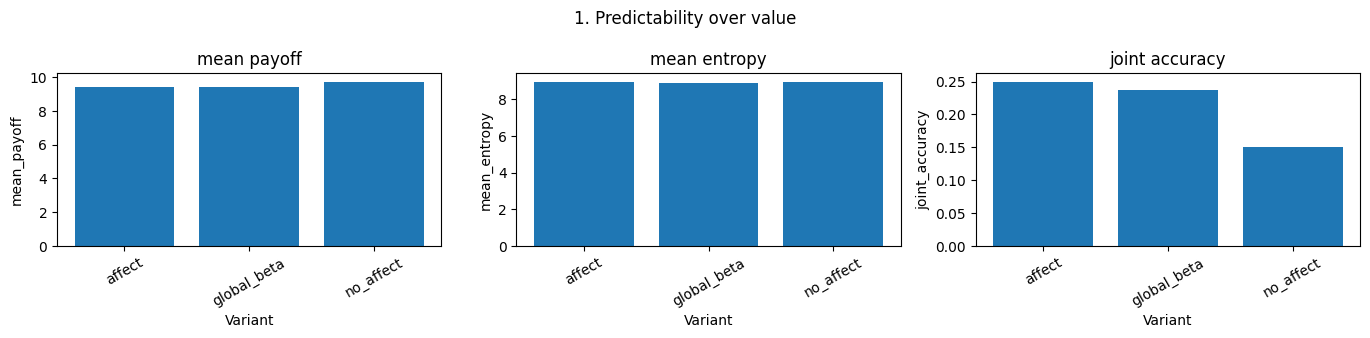

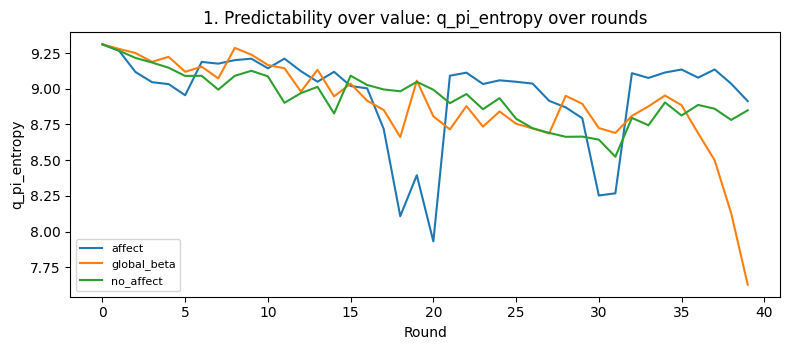

Question: Does confidence track partner predictability more directly than realized payoff?
What To Look For: Compare payoff, policy entropy, predictive evidence, and model-fitness tables.


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,predictability_value_demo,affect,80,9.40000,752.0,8.959971,0.2500,-0.670965,1.0,4
1,predictability_value_demo,global_beta,80,9.45000,756.0,8.897229,0.2375,-0.665232,1.0,4
2,predictability_value_demo,no_affect,80,9.74375,779.5,8.936046,0.1500,-0.629400,1.0,4


Lower entropy means more decisive policy selection in this demo-scale readout.


,experiment_id,variant_id,mean_entropy
1,predictability_value_demo,global_beta,8.897229
2,predictability_value_demo,no_affect,8.936046
0,predictability_value_demo,affect,8.959971


Joint accuracy is a model-state check, not the whole behavioral story.


...

,variant_id,n_partner_seed_units,reward_proxy,reward_proxy_constant,alignment,corr_precision_surprise,corr_precision_reward,corr_surprise_reward,corr_precision_active_encounters,corr_surprise_active_encounters,...,abs_corr_reward_active_encounters,active_encounter_min,active_encounter_max,active_encounter_imbalance,surprise_dominates_reward,partial_corr_precision_surprise,partial_corr_precision_reward,abs_partial_corr_precision_surprise,abs_partial_corr_precision_reward,partial_surprise_dominates_reward
0,affect,8,active_mean_payoff,False,active_encounter,-0.593397,0.102324,-0.255714,-0.204261,-0.210788,...,0.737706,2.0,26.0,13.0,True,-0.664733,0.381844,0.664733,0.381844,True
1,global_beta,8,active_mean_payoff,False,active_encounter,-0.220651,-0.745403,0.028875,-0.556444,0.132554,...,0.857681,2.0,24.0,12.0,False,-0.368427,-0.677500,0.368427,0.677500,False


Analysis table: outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/notebook_analysis/deployment_dissociation_summary.csv


,variant_id,total_payoff,mean_accuracy,mean_stance_accuracy,mean_joint_accuracy,mean_q_pi_entropy,predictive_log_score,delta_total_payoff_vs_affect,delta_mean_accuracy_vs_affect,delta_mean_stance_accuracy_vs_affect,delta_mean_joint_accuracy_vs_affect,delta_mean_q_pi_entropy_vs_affect,delta_predictive_log_score_vs_affect
0,affect,376.00,0.4375,0.575,0.2500,8.959971,-0.670965,0.00,0.000,0.000,0.0000,0.000000,0.000000
1,global_beta,378.00,0.3875,0.750,0.2375,8.897229,-0.665232,2.00,-0.050,0.175,-0.0125,-0.062742,0.005733
2,no_affect,389.75,0.2625,0.650,0.1500,8.936046,-0.629400,13.75,-0.175,0.075,-0.1000,-0.023925,0.041565


Analysis table: outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/notebook_analysis/final_round_summary.csv


,variant_id,seed,total_payoff,mean_accuracy,mean_stance_accuracy,mean_joint_accuracy,mean_q_pi_entropy,mean_abs_step_efe,planning_cost,planning_cost_ratio,total_log_evidence,mean_round_log_evidence
0,affect,101,364.5,0.525,0.775,0.350,9.091354,15.451854,6718464.0,1.0,-28.449702,-0.711243
1,affect,102,387.5,0.350,0.375,0.150,8.828589,15.377722,6718464.0,1.0,-25.227469,-0.630687
2,global_beta,101,387.0,0.625,0.750,0.400,8.898514,15.596914,6718464.0,1.0,-27.300849,-0.682521
3,global_beta,102,369.0,0.150,0.750,0.075,8.895944,16.379912,6718464.0,1.0,-25.917671,-0.647942
4,no_affect,101,411.0,0.350,0.500,0.200,8.946598,14.919121,6718464.0,1.0,-23.099697,-0.577492
5,no_affect,102,368.5,0.175,0.800,0.100,8.925494,16.464768,6718464.0,1.0,-27.252304,-0.681308


In [7]:
show_demo("predictability_value", predictability_value_results)
interpretation_card("predictability_value", predictability_value_results)
display_analysis_tables([Path(p) for p in predictability_value_results.attrs.get("result_paths", [])], ["model_fitness_correlation_summary.csv", "deployment_dissociation_summary.csv", "final_round_summary.csv"])


## 6. Deployment-Ablation Demo: Run And Analyze

Config: `configs/demo/02_deployment_ablation.toml`

**Question.** Is affective precision doing its work by changing policy deployment, or by giving the model extra knowledge?

**What To Look For.** The tracked-only lesion keeps the confidence tracker visible while blocking the route into action precision. Read entropy and deployment summaries before making a payoff claim.


In [8]:
deployment_ablation_results = run_demo("deployment_ablation")


Demo config: configs/demo/02_deployment_ablation.toml
Paper analogue: configs/paper/02_deployment_ablation.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/02_deployment_ablation.toml --output-dir outputs --batch-name notebook_demo_02_deployment_ablation --workers 1


/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/pomdp.py:246: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(
/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/runtime.py:286: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(


Saved 160 rows to outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/results.csv --output-dir outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/notebook_analysis
Per-variant final summary
  variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
      affect           385.5000               NaN         0.2250
 global_beta           369.0000               NaN         0.4000
    lesioned           378.0000               NaN         0.3750
no_epistemic           382.0000               NaN         0.4500

Hypothesis summary
hypothesis                        label  available                                                                  summary  primary_metric secondary_me

Rows: 160


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,deployment_ablation_demo,affect,40,9.6375,385.5,8.885305,0.175,-0.672867,1.0,4
1,deployment_ablation_demo,global_beta,40,9.2250,369.0,8.776910,0.225,-0.611014,1.0,4
2,deployment_ablation_demo,lesioned,40,9.4500,378.0,8.936762,0.225,-0.722195,1.0,4
3,deployment_ablation_demo,no_epistemic,40,9.5500,382.0,9.025794,0.325,-0.725394,1.0,4


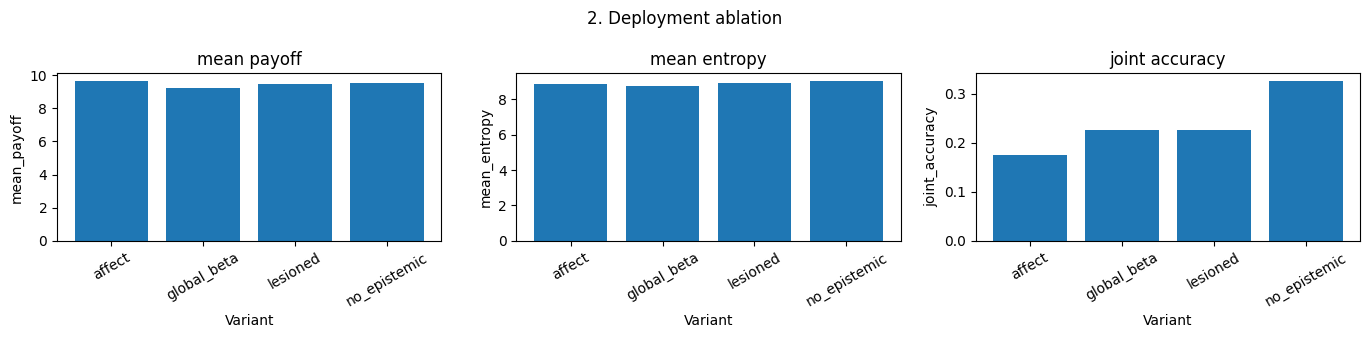

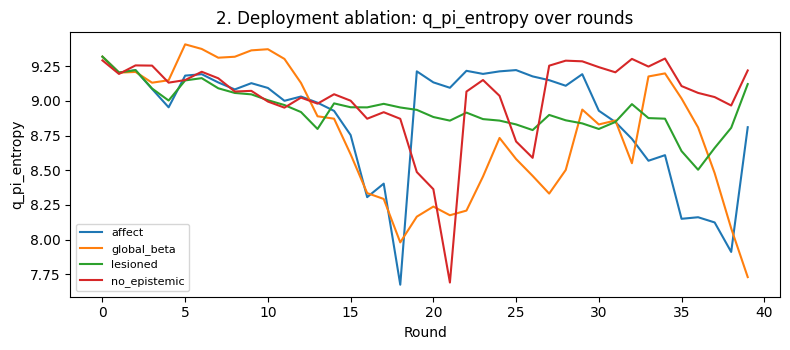

Question: Does affective precision matter because it changes action deployment, not because it adds new observations?
What To Look For: Look for lower entropy through beta-to-gamma deployment while payoff remains nearly matched.


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,deployment_ablation_demo,affect,40,9.6375,385.5,8.885305,0.175,-0.672867,1.0,4
1,deployment_ablation_demo,global_beta,40,9.2250,369.0,8.776910,0.225,-0.611014,1.0,4
2,deployment_ablation_demo,lesioned,40,9.4500,378.0,8.936762,0.225,-0.722195,1.0,4
3,deployment_ablation_demo,no_epistemic,40,9.5500,382.0,9.025794,0.325,-0.725394,1.0,4


Lower entropy means more decisive policy selection in this demo-scale readout.


,experiment_id,variant_id,mean_entropy
1,deployment_ablation_demo,global_beta,8.776910
0,deployment_ablation_demo,affect,8.885305
2,deployment_ablation_demo,lesioned,8.936762
3,deployment_ablation_demo,no_epistemic,9.025794


Joint accuracy is a model-state check, not the whole behavioral story.


...

,variant_id,total_payoff,mean_accuracy,mean_stance_accuracy,mean_joint_accuracy,mean_q_pi_entropy,predictive_log_score,delta_total_payoff_vs_affect,delta_mean_accuracy_vs_affect,delta_mean_stance_accuracy_vs_affect,delta_mean_joint_accuracy_vs_affect,delta_mean_q_pi_entropy_vs_affect,delta_predictive_log_score_vs_affect
0,affect,385.5,0.225,0.525,0.175,8.885305,-0.672867,0.0,0.000,0.000,0.00,0.000000,0.000000
1,global_beta,369.0,0.400,0.500,0.225,8.776910,-0.611014,-16.5,0.175,-0.025,0.05,-0.108395,0.061852
2,lesioned,378.0,0.375,0.650,0.225,8.936762,-0.722195,-7.5,0.150,0.125,0.05,0.051457,-0.049328
3,no_epistemic,382.0,0.450,0.750,0.325,9.025794,-0.725394,-3.5,0.225,0.225,0.15,0.140489,-0.052528


Analysis table: outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/notebook_analysis/hypothesis_summary.csv


,hypothesis,label,available,summary,primary_metric,secondary_metric
0,H0,policy_openness,True,policy-space openness gates affective precisio...,NaN,4
1,H1,model_fitness,True,precision tracks model reliability rather than...,1.0,0
2,H2,deployment,True,NaN,-7.5,0.05000000000000002
3,H3,locality_global_precision,True,local beta and global beta separate signal qua...,NaN,NaN
4,H4,social_allocation,True,agent-choice settings expose partner approach ...,4.0,partner_idx
5,H5,timescale_volatility,False,affect should be most visible after social vol...,0.0,NaN
6,H6,perturbation_phenotypes,False,perturbation phenotypes are task-regime depend...,NaN,NaN
7,H7,signal_source,False,partner-action surprisal should stay cleaner t...,NaN,NaN
8,H8,observation_noise_robustness,False,beta inertia may stabilize or slow behavior un...,NaN,NaN


Analysis table: outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/notebook_analysis/final_round_summary.csv


,variant_id,seed,total_payoff,mean_accuracy,mean_stance_accuracy,mean_joint_accuracy,mean_q_pi_entropy,mean_abs_step_efe,planning_cost,planning_cost_ratio,total_log_evidence,mean_round_log_evidence
0,affect,102,385.5,0.225,0.525,0.175,8.885305,16.333054,6718464.0,1.0,-26.914663,-0.672867
1,global_beta,102,369.0,0.400,0.500,0.225,8.776910,16.126421,6718464.0,1.0,-24.440579,-0.611014
2,lesioned,102,378.0,0.375,0.650,0.225,8.936762,16.324908,6718464.0,1.0,-28.887781,-0.722195
3,no_epistemic,102,382.0,0.450,0.750,0.325,9.025794,16.983295,6718464.0,1.0,-29.015775,-0.725394


In [9]:
show_demo("deployment_ablation", deployment_ablation_results)
interpretation_card("deployment_ablation", deployment_ablation_results)
display_analysis_tables([Path(p) for p in deployment_ablation_results.attrs.get("result_paths", [])], ["deployment_dissociation_summary.csv", "hypothesis_summary.csv", "final_round_summary.csv"])


## 7. Partner-Selection Demo: Run And Analyze

Config: `configs/demo/03_partner_selection.toml`

**Question.** Once the agent can choose partners, does local confidence change the social sampling pattern?

**What To Look For.** Inspect selected-partner spread and partner-choice summaries. A useful result can be allocation reorganization even when total payoff stays close.


In [10]:
partner_selection_results = run_demo("partner_selection")


Demo config: configs/demo/03_partner_selection.toml
Paper analogue: configs/paper/03_partner_selection.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/03_partner_selection.toml --output-dir outputs --batch-name notebook_demo_03_partner_selection --workers 1


/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/pomdp.py:246: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(
/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/runtime.py:286: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(


Saved 120 rows to outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/results.csv --output-dir outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/notebook_analysis
Per-variant final summary
 variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
     affect           417.5000               NaN         0.5000
global_beta           392.0000               NaN         0.4000
  no_affect           399.0000               NaN         0.5000

Hypothesis summary
hypothesis                        label  available                                                                  summary  primary_metric secondary_metric
        H0              policy_openness       True                  policy-space o

Rows: 120


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,partner_selection_demo,affect,40,10.4375,417.5,8.398917,0.300,-0.563184,1.0,4
1,partner_selection_demo,global_beta,40,9.8000,392.0,8.839678,0.125,-0.650721,1.0,4
2,partner_selection_demo,no_affect,40,9.9750,399.0,8.864432,0.325,-0.627264,1.0,4


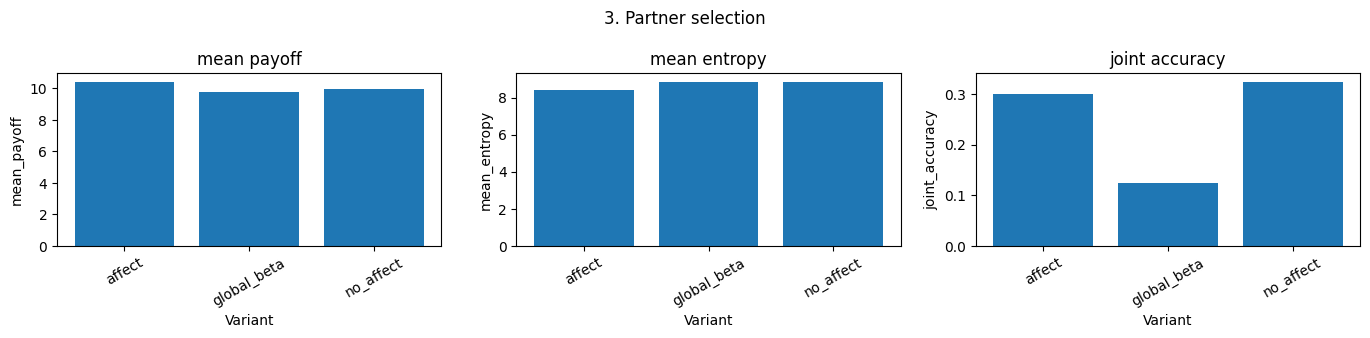

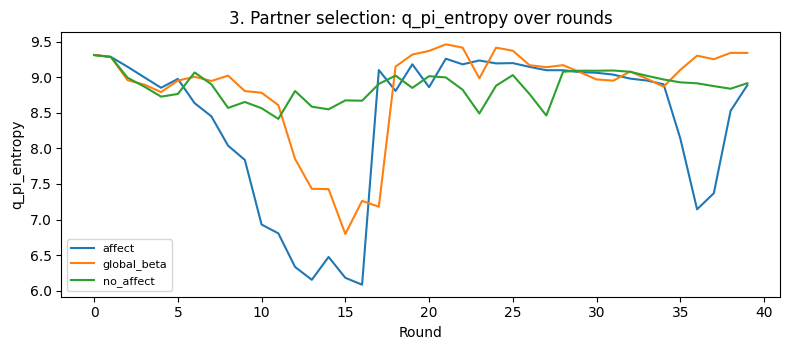

Question: Does partner-local precision reshape who the agent chooses to engage?
What To Look For: Inspect selected-partner rates, partner-type summaries, and entropy; avoid a one-type preference or payoff headline.


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,partner_selection_demo,affect,40,10.4375,417.5,8.398917,0.300,-0.563184,1.0,4
1,partner_selection_demo,global_beta,40,9.8000,392.0,8.839678,0.125,-0.650721,1.0,4
2,partner_selection_demo,no_affect,40,9.9750,399.0,8.864432,0.325,-0.627264,1.0,4


Lower entropy means more decisive policy selection in this demo-scale readout.


,experiment_id,variant_id,mean_entropy
0,partner_selection_demo,affect,8.398917
1,partner_selection_demo,global_beta,8.839678
2,partner_selection_demo,no_affect,8.864432


Joint accuracy is a model-state check, not the whole behavioral story.


,experiment_id,variant_id,joint_accuracy
2,partner_selection_demo,no_affect,0.325
0,partner_selection_demo,affect,0.300
1,partner_selection_demo,global_beta,0.125


Partner-type mix unavailable in this output.


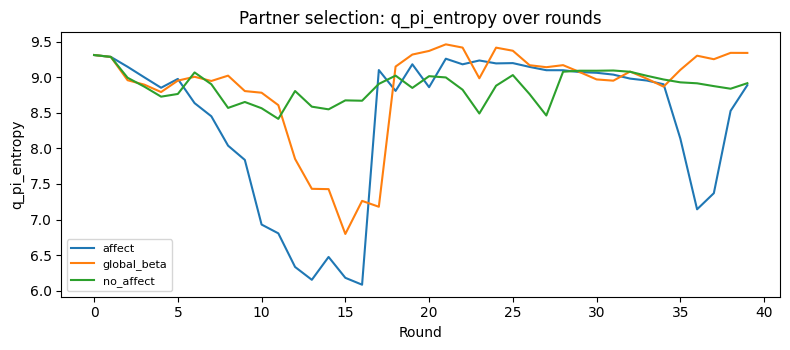

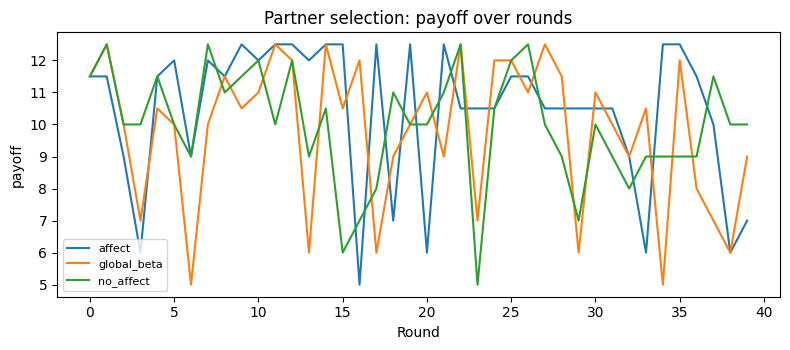

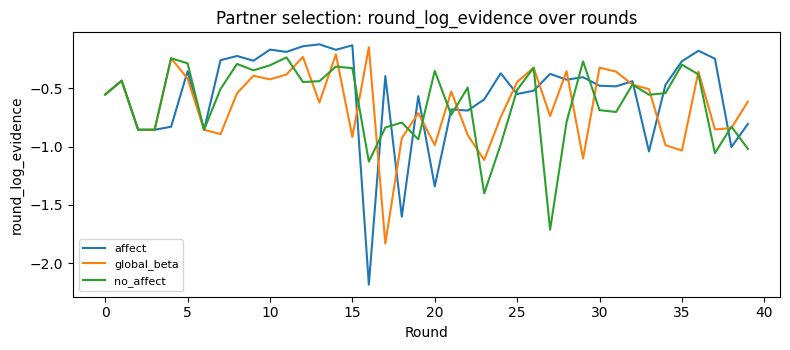

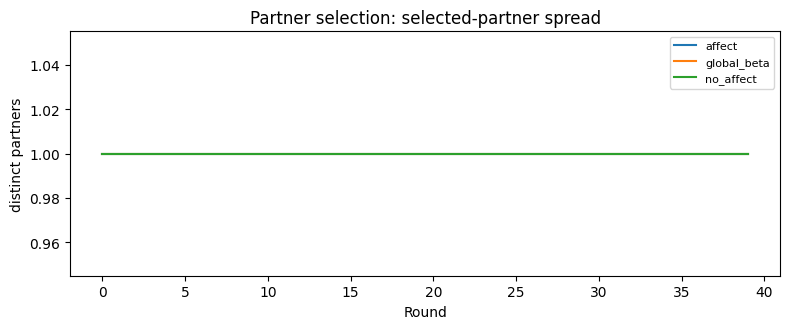

Analysis table: outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/notebook_analysis/partner_choice_summary.csv


,variant_id,seed,selected_partner,selection_count,mean_payoff,mean_q_pi_entropy,mean_selected_partner_beta,total_choices,selection_rate
0,affect,103,0,21,10.904762,8.071000,1.026473,40,0.525
1,affect,103,1,16,10.093750,8.731174,0.922610,40,0.400
2,affect,103,2,2,9.000000,8.809376,1.021116,40,0.050
3,affect,103,3,1,9.000000,9.148147,1.041663,40,0.025
4,global_beta,103,0,22,10.386364,8.735597,1.108940,40,0.550
5,global_beta,103,1,8,9.187500,8.902077,1.350966,40,0.200
6,global_beta,103,2,7,9.000000,8.977640,1.408853,40,0.175
7,global_beta,103,3,3,9.000000,9.114631,1.140515,40,0.075
8,no_affect,103,0,25,10.540000,8.815828,NaN,40,0.625
9,no_affect,103,1,6,9.750000,8.970844,NaN,40,0.150


Analysis table: outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/notebook_analysis/partner_model_fitness_summary.csv


,variant_id,seed,partner_idx,beta_mean,precision_mean,active_precision_mean,surprise_mean,active_surprise_mean,reward_signal_mean,active_mean_payoff,active_accuracy,active_encounters
0,affect,103,0,1.200481,0.992832,1.207338,0.661250,0.516287,NaN,10.904762,0.571429,21
1,affect,103,1,1.026781,1.046656,1.219236,0.679047,0.595921,NaN,10.093750,0.375000,16
2,affect,103,2,1.027195,0.973889,0.979717,0.757694,0.647475,NaN,9.000000,1.000000,2
3,affect,103,3,1.039579,0.962004,0.960004,0.855666,0.855666,NaN,9.000000,0.000000,1
4,global_beta,103,0,1.212198,0.948612,1.039686,0.638128,0.584878,NaN,10.386364,0.545455,22
5,global_beta,103,1,1.212198,0.948612,0.821851,0.745966,0.799461,NaN,9.187500,0.125000,8
6,global_beta,103,2,1.212198,0.948612,0.830679,0.840595,0.726321,NaN,9.000000,0.428571,7
7,global_beta,103,3,1.212198,0.948612,0.893942,0.762464,0.560525,NaN,9.000000,0.000000,3


Analysis table: outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/notebook_analysis/final_round_summary.csv


,variant_id,seed,total_payoff,mean_accuracy,mean_stance_accuracy,mean_joint_accuracy,mean_q_pi_entropy,mean_abs_step_efe,planning_cost,planning_cost_ratio,total_log_evidence,mean_round_log_evidence
0,affect,103,417.5,0.5,0.425,0.300,8.398917,15.397124,6718464.0,1.0,-22.527375,-0.563184
1,global_beta,103,392.0,0.4,0.400,0.125,8.839678,15.492591,6718464.0,1.0,-26.028826,-0.650721
2,no_affect,103,399.0,0.5,0.675,0.325,8.864432,15.885876,6718464.0,1.0,-25.090558,-0.627264


In [11]:
show_demo("partner_selection", partner_selection_results)
interpretation_card("partner_selection", partner_selection_results)
partner_selection_mix(partner_selection_results)
plot_profile_metrics(partner_selection_results, "Partner selection")
display_analysis_tables([Path(p) for p in partner_selection_results.attrs.get("result_paths", [])], ["partner_choice_summary.csv", "partner_model_fitness_summary.csv", "final_round_summary.csv"])

## 8. Betrayal-Adaptation Demo: Run And Analyze

Config: `configs/demo/04_betrayal_adaptation.toml`

**Question.** What happens when a previously reliable partner changes stance?

**What To Look For.** Read this as a temporal-dependency test. Confidence can sharpen action selection, but after a switch the same sharpness can expose whether the agent reallocates, perseverates, or updates its partner model.


In [12]:
betrayal_adaptation_results = run_demo("betrayal_adaptation")


Demo config: configs/demo/04_betrayal_adaptation.toml
Paper analogue: configs/paper/04_betrayal_adaptation.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/04_betrayal_adaptation.toml --output-dir outputs --batch-name notebook_demo_04_betrayal_adaptation --workers 1


/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/pomdp.py:246: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(
/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/runtime.py:286: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(


Saved 400 rows to outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/results.csv --output-dir outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/notebook_analysis
Per-variant final summary
 variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
     affect           490.2500           10.2530         0.5400
global_beta           466.0000           13.4350         0.2300
   lesioned           466.2500            4.5962         0.2600
  no_affect           466.2500            4.5962         0.2600

Hypothesis summary
hypothesis                        label  available                                                                  summary  primary_metric secondary_metric


Rows: 400


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,betrayal_adaptation_demo,affect,100,9.805,980.5,8.509655,0.33,-0.636490,1.0,4
1,betrayal_adaptation_demo,global_beta,100,9.320,932.0,8.852750,0.15,-0.675241,1.0,4
2,betrayal_adaptation_demo,lesioned,100,9.325,932.5,8.903479,0.15,-0.680393,1.0,4
3,betrayal_adaptation_demo,no_affect,100,9.325,932.5,8.903479,0.15,-0.680393,1.0,4


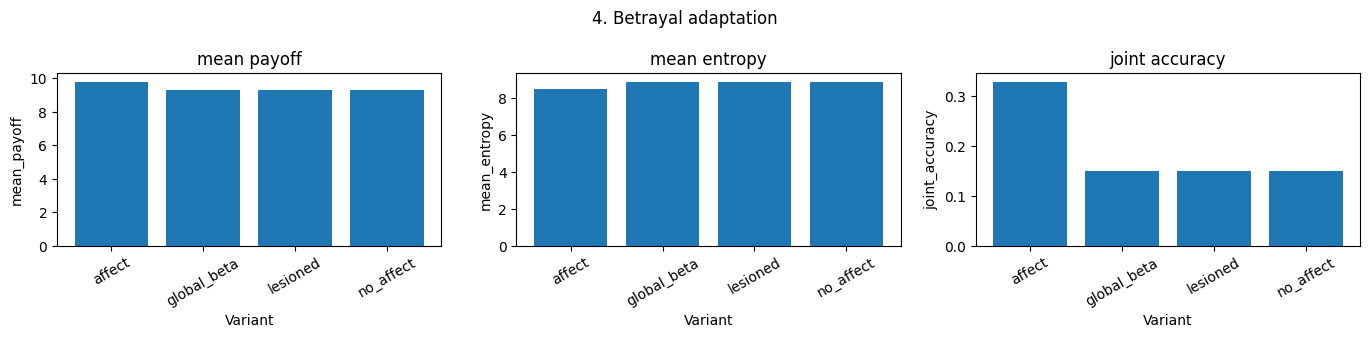

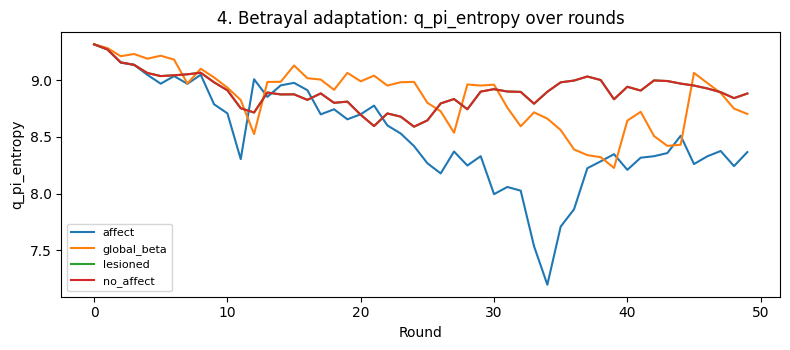

Question: What happens when confidence accumulated under cooperation meets a sudden stance change?
What To Look For: Read entropy, joint accuracy, reallocation, and post-switch phase summaries together.


,experiment_id,variant_id,rows,mean_payoff,total_payoff,mean_entropy,joint_accuracy,mean_log_evidence,mean_planning_cost,distinct_selected_partners
0,betrayal_adaptation_demo,affect,100,9.805,980.5,8.509655,0.33,-0.636490,1.0,4
1,betrayal_adaptation_demo,global_beta,100,9.320,932.0,8.852750,0.15,-0.675241,1.0,4
2,betrayal_adaptation_demo,lesioned,100,9.325,932.5,8.903479,0.15,-0.680393,1.0,4
3,betrayal_adaptation_demo,no_affect,100,9.325,932.5,8.903479,0.15,-0.680393,1.0,4


Lower entropy means more decisive policy selection in this demo-scale readout.


,experiment_id,variant_id,mean_entropy
0,betrayal_adaptation_demo,affect,8.509655
1,betrayal_adaptation_demo,global_beta,8.852750
2,betrayal_adaptation_demo,lesioned,8.903479
3,betrayal_adaptation_demo,no_affect,8.903479


Joint accuracy is a model-state check, not the whole behavioral story.


,experiment_id,variant_id,joint_accuracy
0,betrayal_adaptation_demo,affect,0.33
1,betrayal_adaptation_demo,global_beta,0.15
2,betrayal_adaptation_demo,lesioned,0.15
3,betrayal_adaptation_demo,no_affect,0.15


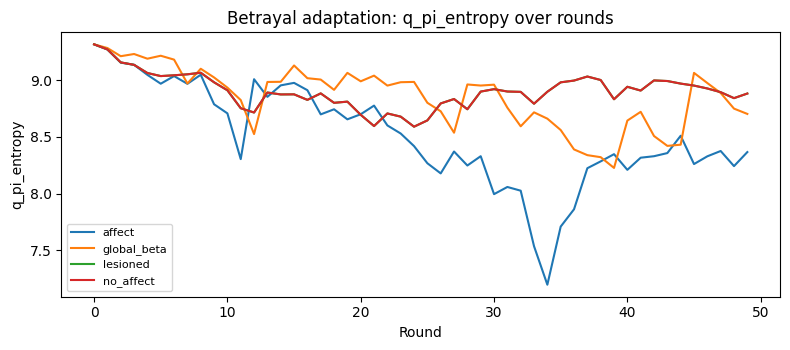

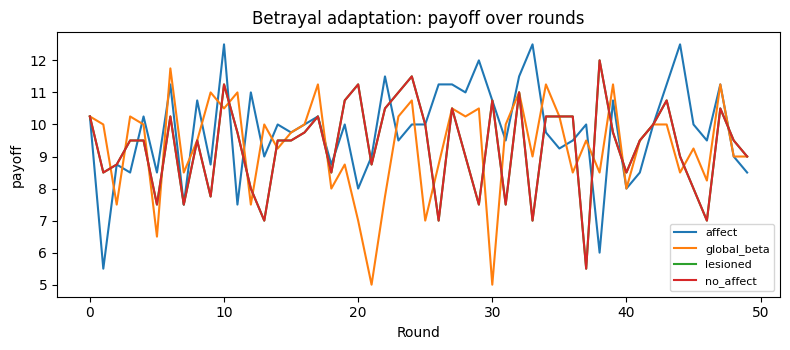

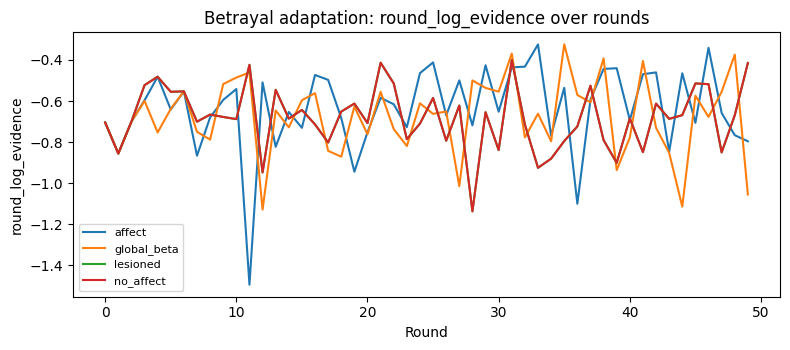

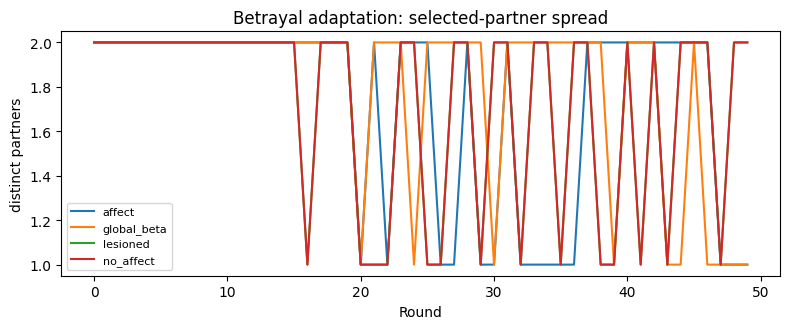

Analysis table: outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/notebook_analysis/betrayal_phase_summary.csv


,variant_id,seed,partner_idx,switch_round,switch_kind,phase,encounters,mean_payoff,mean_q_pi_entropy,selected_partner_rate,mean_selected_action
0,affect,202,0,15,scheduled_stance,pre_switch,5,9.30,9.167281,1.0,1.00
1,affect,202,0,15,scheduled_stance,acute_post_switch,10,9.20,7.931925,1.0,0.80
2,affect,202,0,15,scheduled_stance,post_acute_tail,1,10.00,7.537335,1.0,0.00
3,affect,203,0,15,scheduled_stance,pre_switch,2,8.50,9.000806,1.0,4.50
4,affect,203,0,15,scheduled_stance,acute_post_switch,2,9.00,9.080631,1.0,1.00
5,affect,203,0,15,scheduled_stance,post_acute_tail,0,NaN,NaN,NaN,NaN
6,global_beta,202,0,15,scheduled_stance,pre_switch,5,8.80,9.294048,1.0,1.80
7,global_beta,202,0,15,scheduled_stance,acute_post_switch,8,9.25,8.558617,1.0,0.75
8,global_beta,202,0,15,scheduled_stance,post_acute_tail,0,NaN,NaN,NaN,NaN
9,global_beta,203,0,15,scheduled_stance,pre_switch,3,9.00,9.090143,1.0,2.00


Analysis table: outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/notebook_analysis/betrayal_reallocation_summary.csv


,variant_id,seed,partner_idx,switch_event_idx,switch_round,switch_kind,post_switch_decisions,reencounters,returned_to_partner,decisions_to_first_reencounter,rounds_to_first_reencounter,reencounter_selection_rate,mean_payoff_on_reencounter,mean_q_pi_entropy_on_reencounter
0,affect,202,0,0,15,scheduled_stance,35,11,True,1.0,1.0,0.314286,9.272727,7.896053
1,affect,203,0,0,15,scheduled_stance,35,2,True,0.0,0.0,0.057143,9.000000,9.080631
2,global_beta,202,0,0,15,scheduled_stance,35,8,True,1.0,1.0,0.228571,9.250000,8.558617
3,global_beta,203,0,0,15,scheduled_stance,35,1,True,0.0,0.0,0.028571,9.000000,9.031839
4,lesioned,202,0,0,15,scheduled_stance,35,1,True,16.0,16.0,0.028571,5.000000,8.619186
5,lesioned,203,0,0,15,scheduled_stance,35,5,True,0.0,0.0,0.142857,8.500000,8.972972
6,no_affect,202,0,0,15,scheduled_stance,35,1,True,16.0,16.0,0.028571,5.000000,8.619186
7,no_affect,203,0,0,15,scheduled_stance,35,5,True,0.0,0.0,0.142857,8.500000,8.972972


Analysis table: outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/notebook_analysis/betrayal_misdeployment_summary.csv


,variant_id,seed,partner_idx,switch_event_idx,switch_round,switch_kind,window,encounters,mean_payoff,mean_q_pi_entropy,wrong_type_rate,bad_payoff_rate,low_entropy_rate,overconfident_wrong_type_rate,overconfident_bad_payoff_rate,selected_partner_rate,entropy_cutoff
0,affect,202,0,0,15,scheduled_stance,10,10,9.20,7.931925,0.000,0.0,0.6,0.0,0.0,1.0,7.836438
1,affect,203,0,0,15,scheduled_stance,10,2,9.00,9.080631,0.000,0.0,0.0,0.0,0.0,1.0,7.836438
2,global_beta,202,0,0,15,scheduled_stance,10,8,9.25,8.558617,0.125,0.0,0.5,0.0,0.0,1.0,8.800280
3,global_beta,203,0,0,15,scheduled_stance,10,1,9.00,9.031839,0.000,0.0,0.0,0.0,0.0,1.0,8.800280
4,lesioned,202,0,0,15,scheduled_stance,10,1,5.00,8.619186,0.000,0.0,1.0,0.0,0.0,1.0,8.827730
5,lesioned,203,0,0,15,scheduled_stance,10,5,8.50,8.972972,0.400,0.0,0.0,0.0,0.0,1.0,8.827730
6,no_affect,202,0,0,15,scheduled_stance,10,1,5.00,8.619186,0.000,0.0,1.0,0.0,0.0,1.0,8.827730
7,no_affect,203,0,0,15,scheduled_stance,10,5,8.50,8.972972,0.400,0.0,0.0,0.0,0.0,1.0,8.827730


Analysis table: outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/notebook_analysis/evidence_effect_summary.csv


,readout,metric,treatment_variant,reference_variant,treatment_mean,reference_mean,difference,cohen_d,bootstrap_ci_low,bootstrap_ci_high,n_treatment,n_reference
0,final,total_payoff,affect,no_affect,490.250000,466.250000,24.000000,3.020721,13.500000,34.500000,2,2
1,final,mean_q_pi_entropy,affect,no_affect,8.509655,8.903479,-0.393824,-0.972514,-0.863019,0.075370,2,2
2,final,mean_joint_accuracy,affect,no_affect,0.330000,0.150000,0.180000,1.897367,0.060000,0.300000,2,2
3,final,mean_stance_accuracy,affect,no_affect,0.650000,0.730000,-0.080000,-0.883452,-0.180000,0.020000,2,2
4,model_fitness,abs_corr_precision_surprise_minus_reward,affect,NaN,0.022248,NaN,0.022248,NaN,-0.456439,0.500935,2,0
5,model_fitness,abs_partial_corr_precision_surprise_minus_reward,affect,NaN,0.717555,NaN,0.717555,NaN,0.717555,0.717555,1,0
6,model_fitness,abs_corr_precision_surprise_minus_reward,global_beta,NaN,-0.400142,NaN,-0.400142,NaN,-0.485391,-0.314893,2,0
7,model_fitness,abs_partial_corr_precision_surprise_minus_reward,global_beta,NaN,0.117727,NaN,0.117727,NaN,0.117727,0.117727,1,0
8,model_fitness,abs_corr_precision_surprise_minus_reward,lesioned,NaN,0.268123,NaN,0.268123,NaN,-0.135108,0.671354,2,0
9,model_fitness,abs_partial_corr_precision_surprise_minus_reward,lesioned,NaN,0.532446,NaN,0.532446,NaN,0.532446,0.532446,1,0


In [13]:
show_demo("betrayal_adaptation", betrayal_adaptation_results)
interpretation_card("betrayal_adaptation", betrayal_adaptation_results)
plot_profile_metrics(betrayal_adaptation_results, "Betrayal adaptation")
display_analysis_tables([Path(p) for p in betrayal_adaptation_results.attrs.get("result_paths", [])], ["betrayal_phase_summary.csv", "betrayal_reallocation_summary.csv", "betrayal_misdeployment_summary.csv", "evidence_effect_summary.csv"])


## 9. Appendix-Level Extensions

The next three demos are included by default. They are useful because the paper's appendix/profile material is where the mechanism becomes less one-dimensional: gain, priors, reengagement, confidence, entropy, partner choice, and payoff can move differently.

## 10. Alpha-Sweep Demo: Run And Analyze

Config: `configs/demo/05a_alpha_sweep.toml`

**Question.** What does the affective gain parameter change?

**What To Look For.** The appendix-level lesson is that gain controls confidence amplitude and policy commitment. A larger confidence movement is not automatically a better payoff regime.


In [14]:
alpha_sweep_results = run_demo("alpha_sweep")


Demo config: configs/demo/05a_alpha_sweep.toml
Paper analogue: configs/paper/05a_alpha_sweep.toml
Skipping 5a. Alpha sweep. Add 'alpha_sweep' to SELECTED_DEMOS to run it.


In [15]:
show_appendix_demo("alpha_sweep", alpha_sweep_results)
interpretation_card("alpha_sweep", alpha_sweep_results)
display_analysis_tables([Path(p) for p in alpha_sweep_results.attrs.get("result_paths", [])], ["affective_movement_summary.csv", "phenotype_validation_summary.csv", "betrayal_phase_summary.csv", "hypothesis_summary.csv"])


Appendix-Level Extensions: 5a. Alpha sweep
No rows loaded for 5a. Alpha sweep.
No rows available for 5a. Alpha sweep.
Question: How does gain change confidence amplitude and policy commitment?
What To Look For: Use appendix-style profile plots: gain changes confidence amplitude, entropy, and commitment without implying a monotone payoff ranking.
No data loaded yet.
No compact analysis tables found yet. Run with RUN_ANALYSIS = True to generate them.


## 11. Prior-Factorial Demo: Run And Analyze

Config: `configs/demo/05b_prior_factorial.toml`

**Question.** How do trust priors and precision gain combine into profile-like behavior?

**What To Look For.** Compare profile rows across open, betrayal, and partner-choice sub-experiments. The point is the shape of the trade-off, not a single winning profile.


In [16]:
prior_factorial_results = run_demo("prior_factorial")


Demo config: configs/demo/05b_prior_factorial.toml
Paper analogue: configs/paper/05b_prior_factorial.toml
Skipping 5b. Prior x gain factorial. Add 'prior_factorial' to SELECTED_DEMOS to run it.


In [17]:
show_appendix_demo("prior_factorial", prior_factorial_results)
interpretation_card("prior_factorial", prior_factorial_results)
display_analysis_tables([Path(p) for p in prior_factorial_results.attrs.get("result_paths", [])], ["phenotype_validation_summary.csv", "partner_choice_summary.csv", "betrayal_reallocation_summary.csv", "hypothesis_summary.csv"])


Appendix-Level Extensions: 5b. Prior x gain factorial
No rows loaded for 5b. Prior x gain factorial.
No rows available for 5b. Prior x gain factorial.
Question: How do starting trust priors and precision gain combine into computational profiles?
What To Look For: Compare profile-level payoff, entropy, partner choice, and compact phenotype validation tables.
No data loaded yet.
No compact analysis tables found yet. Run with RUN_ANALYSIS = True to generate them.


## 12. Forgiveness Demo: Run And Analyze

Config: `configs/demo/05c_forgiveness.toml`

**Question.** Does behavioral reengagement mean confidence has recovered?

**What To Look For.** This demo is intentionally appendix-like. Read reengagement, beta movement, and payoff recovery separately; forgiveness here is a computational dissociation, not a moral label.


In [18]:
forgiveness_results = run_demo("forgiveness")


Demo config: configs/demo/05c_forgiveness.toml
Paper analogue: configs/paper/05c_forgiveness.toml
Skipping 5c. Forgiveness. Add 'forgiveness' to SELECTED_DEMOS to run it.


In [19]:
show_appendix_demo("forgiveness", forgiveness_results)
interpretation_card("forgiveness", forgiveness_results)
display_analysis_tables([Path(p) for p in forgiveness_results.attrs.get("result_paths", [])], ["betrayal_reallocation_summary.csv", "betrayal_phase_summary.csv", "affective_movement_summary.csv", "phenotype_validation_summary.csv"])


Appendix-Level Extensions: 5c. Forgiveness
No rows loaded for 5c. Forgiveness.
No rows available for 5c. Forgiveness.
Question: Can reengagement recover without restored confidence?
What To Look For: Read post-switch reengagement, beta movement, and payoff recovery as separate axes.
No data loaded yet.
No compact analysis tables found yet. Run with RUN_ANALYSIS = True to generate them.


## 13. What This Demo Does Not Prove

These are small, fast analogues. They prove that the public configs, runner, analysis scripts, and visual readouts work together. They do not replace the paper-scale result cards under `results/paper/`, the manuscript source tables, or the row-level data packet.

Full paper result data are available in the public data packet; see root `README.md`.

Use `notebooks/reproduce.ipynb` when the goal is full paper reproduction. Use this notebook when the goal is to understand the mechanism before waiting for larger runs.